# Poisson 2D Flow Matching Analysis

This notebook analyzes the trained Flow Matching model for solving the 2D Poisson equation:

$$-\nabla^2 u = f$$

where $f$ is the source term and $u$ is the solution.

**Contents:**
1. Load trained model and test data
2. Generate samples via ODE integration
3. Compare predictions vs ground truth
4. Error analysis and metrics
5. Visualize the flow trajectory
6. Statistical analysis of model performance

In [1]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

# FlowPDE imports
from flowpde.datasets.apebench import APEBenchProvider
from flowpde.models.unet import UNet
from flowpde.flows.flow_matching import FlowMatching
from flowpde.solvers import ODEFlowSolver

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Load Model and Data

In [2]:
# Configuration (must match training)
SPATIAL_SIZE = 64
BASE_CHANNELS = 64
CHECKPOINT_PATH = project_root / "results" / "poisson_2d_flowmatching" / "checkpoints" / "best_model.pt"

print(f"Loading checkpoint from: {CHECKPOINT_PATH}")
print(f"Checkpoint exists: {CHECKPOINT_PATH.exists()}")

Loading checkpoint from: /home/breziskato/Desktop/projects/FlowPDE/results/poisson_2d_flowmatching/checkpoints/best_model.pt
Checkpoint exists: True


In [3]:
# Create model architecture
model = UNet(
    spatial_dim=2,
    spatial_size=SPATIAL_SIZE,
    base_channels=BASE_CHANNELS,
    solution_channels=1,
    condition_channels=1,
    use_attention=True,
    norm_type="group",
    activation="swish",
    return_spatial=False,
)

# Load checkpoint
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state'])
model = model.to(device)
model.eval()

print(f"Model loaded successfully!")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model loaded successfully!
Parameters: 22,756,353


In [4]:
# Create Flow Matching wrapper
flow = FlowMatching(
    model=model,
    path='linear',
    time_sampler='uniform',
    sigma=0.0,
)
print("Flow Matching initialized")

Flow Matching initialized


In [5]:
# Load test dataset
test_dataset = APEBenchProvider.create(
    pde='poisson_2d',
    problem='forward',
    mode='test',
    cache=True,
    num_points=SPATIAL_SIZE,
    num_train_samples=2000,  # Needed for cache key
    num_test_samples=200,
    torch_device='cpu',  # Load to CPU first
)

print(f"Test dataset loaded: {len(test_dataset)} samples")

/home/breziskato/Desktop/projects/.venv/flowpde/lib/python3.12/site-packages/trainax/_general_trainer.py:7: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


Generating test data for poisson_2d...
Cached test data to: .cache/apebench/poisson_2d/res64_n2000_t1_s0_L10.0
Generated test data: source: (200, 1, 64, 64), solution: (200, 1, 64, 64)
Test dataset loaded: 200 samples


/home/breziskato/Desktop/projects/FlowPDE/flowpde/datasets/apebench/converters.py:47: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:206.)
  tensor = torch.from_numpy(np_array)


## 2. Generate Samples via Flow ODE

In [6]:
def generate_samples(flow, conditions, n_steps=50, solver='dopri5'):
    """
    Generate solution predictions using the flow model.
    
    Integrates: dx/dt = v(x, condition, t) from t=0 to t=1
    """
    flow.model.eval()
    with torch.no_grad():
        samples = flow.sample(
            condition=conditions,
            n_steps=n_steps,
            solver=solver,
        )
    return samples

# Select a batch of test samples
N_SAMPLES = 16
indices = np.random.choice(len(test_dataset), N_SAMPLES, replace=False)

# Get ground truth data
sources = torch.stack([test_dataset[i]['input'] for i in indices])  # (N, 1, 64, 64)
solutions_gt = torch.stack([test_dataset[i]['target'] for i in indices])  # (N, 1, 64, 64)

print(f"Source (f) shape: {sources.shape}")
print(f"Ground truth solution (u) shape: {solutions_gt.shape}")

Source (f) shape: torch.Size([16, 1, 64, 64])
Ground truth solution (u) shape: torch.Size([16, 1, 64, 64])


In [7]:
# Generate predictions
print("Generating predictions...")
sources_device = sources.to(device)

# Use different solvers for comparison
predictions = {}
for solver in ['euler', 'rk4', 'dopri5']:
    n_steps = 100 if solver == 'euler' else 50
    pred = generate_samples(flow, sources_device, n_steps=n_steps, solver=solver)
    predictions[solver] = pred.cpu().view(N_SAMPLES, 1, SPATIAL_SIZE, SPATIAL_SIZE)
    print(f" {solver}: done")

print("\nAll predictions generated!")

Generating predictions...


/home/breziskato/Desktop/projects/.venv/flowpde/lib/python3.12/site-packages/torchdiffeq/_impl/misc.py:15: UserWarning: Euler: Unexpected arguments {'dtype': torch.float32}
  warnings.warn('{}: Unexpected arguments {}'.format(solver.__class__.__name__, unused_kwargs))


 euler: done


/home/breziskato/Desktop/projects/.venv/flowpde/lib/python3.12/site-packages/torchdiffeq/_impl/misc.py:15: UserWarning: RK4: Unexpected arguments {'dtype': torch.float32}
  warnings.warn('{}: Unexpected arguments {}'.format(solver.__class__.__name__, unused_kwargs))


 rk4: done
 dopri5: done

All predictions generated!


## 3. Visual Comparison: Prediction vs Ground Truth

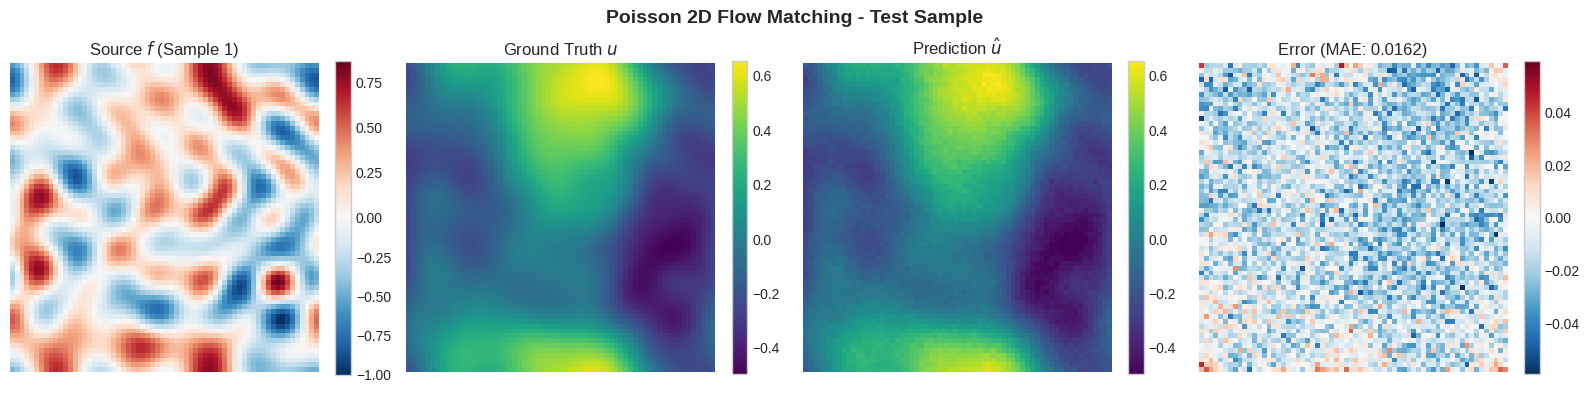

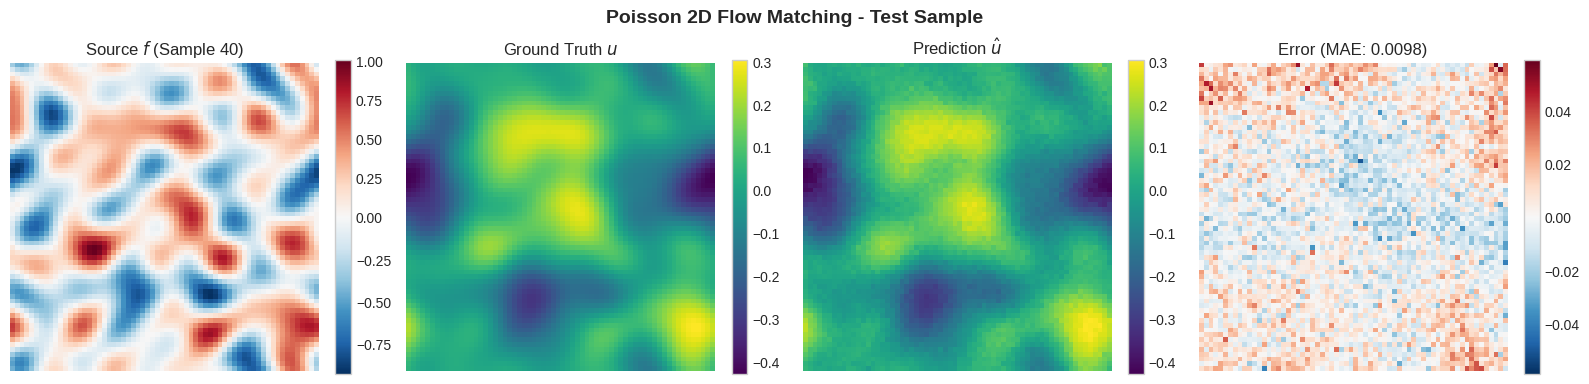

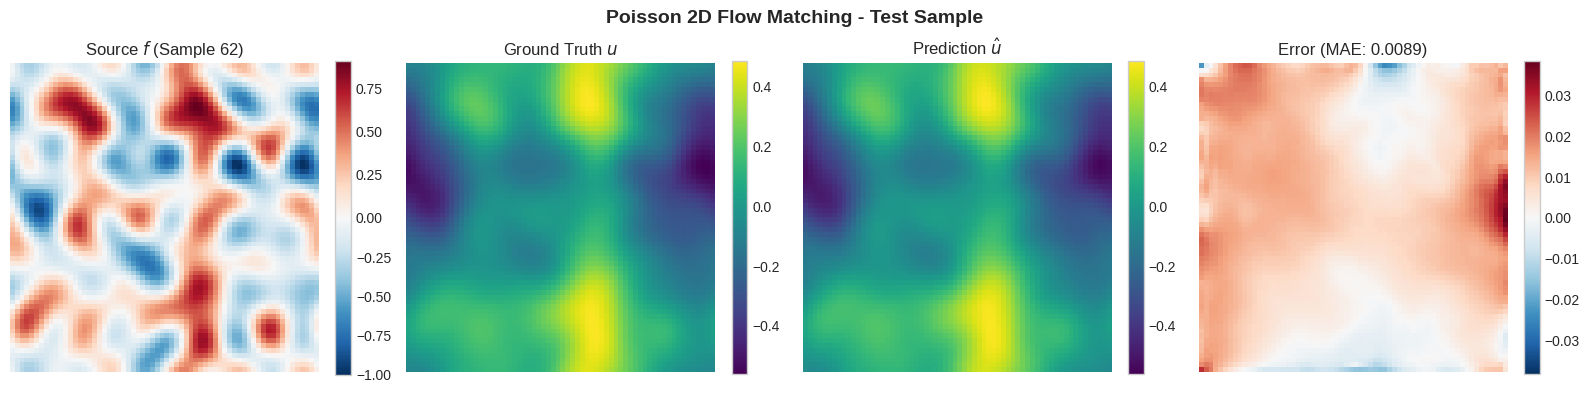

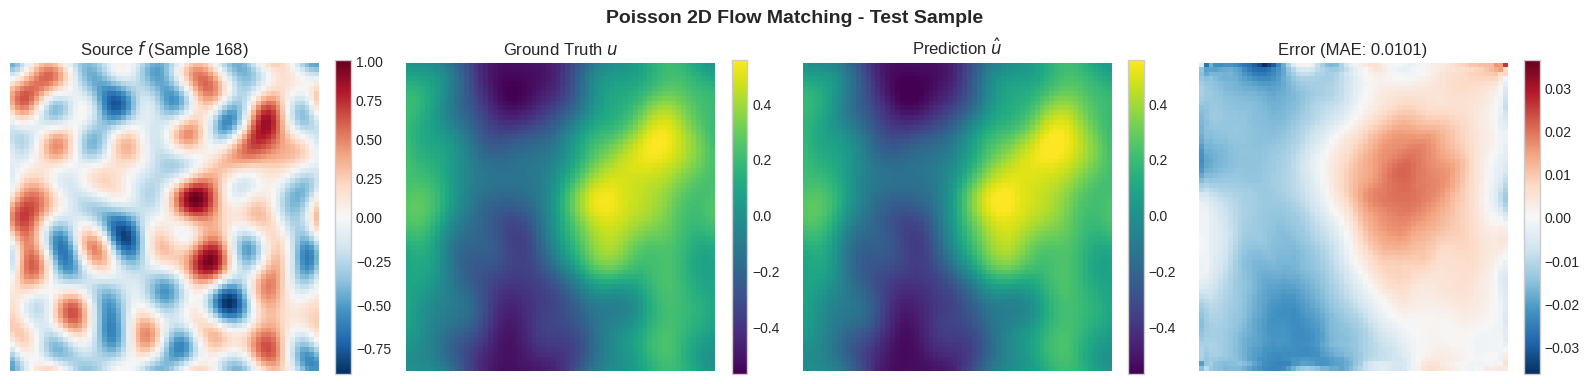

In [8]:
def plot_comparison(source, gt, pred, idx, title=""):
    """
    Create a 4-panel comparison: source, ground truth, prediction, error.
    """
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    # Source term f
    im0 = axes[0].imshow(source.squeeze().numpy(), cmap='RdBu_r', 
                          norm=TwoSlopeNorm(0))
    axes[0].set_title(f'Source $f$ (Sample {idx})', fontsize=12)
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0], fraction=0.046)
    
    # Ground truth solution u
    vmin, vmax = gt.min().item(), gt.max().item()
    im1 = axes[1].imshow(gt.squeeze().numpy(), cmap='viridis', vmin=vmin, vmax=vmax)
    axes[1].set_title('Ground Truth $u$', fontsize=12)
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046)
    
    # Prediction
    im2 = axes[2].imshow(pred.squeeze().numpy(), cmap='viridis', vmin=vmin, vmax=vmax)
    axes[2].set_title('Prediction $\\hat{u}$', fontsize=12)
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.046)
    
    # Error
    error = (pred - gt).squeeze().numpy()
    max_err = np.abs(error).max()
    im3 = axes[3].imshow(error, cmap='RdBu_r', vmin=-max_err, vmax=max_err)
    axes[3].set_title(f'Error (MAE: {np.abs(error).mean():.4f})', fontsize=12)
    axes[3].axis('off')
    plt.colorbar(im3, ax=axes[3], fraction=0.046)
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

# Plot first 4 samples
for i in range(4):
    fig = plot_comparison(
        sources[i], solutions_gt[i], predictions['dopri5'][i], 
        indices[i], title=f"Poisson 2D Flow Matching - Test Sample"
    )
    plt.show()

## 4. Error Analysis and Metrics

In [9]:
def compute_metrics(pred, gt):
    """
    Compute comprehensive error metrics.
    """
    # Flatten for computation
    pred_flat = pred.flatten(start_dim=1)
    gt_flat = gt.flatten(start_dim=1)
    
    # Per-sample metrics
    mse = ((pred_flat - gt_flat) ** 2).mean(dim=1)
    mae = (pred_flat - gt_flat).abs().mean(dim=1)
    
    # Relative L2 error
    rel_l2 = torch.sqrt(mse) / (torch.sqrt((gt_flat ** 2).mean(dim=1)) + 1e-8)
    
    # Peak Signal-to-Noise Ratio (PSNR)
    max_val = gt_flat.abs().max(dim=1).values
    psnr = 20 * torch.log10(max_val / (torch.sqrt(mse) + 1e-8))
    
    return {
        'mse': mse,
        'mae': mae,
        'rmse': torch.sqrt(mse),
        'rel_l2': rel_l2,
        'psnr': psnr,
    }

# Compute metrics for each solver
metrics_all = {}
for solver, pred in predictions.items():
    metrics_all[solver] = compute_metrics(pred, solutions_gt)

# Display metrics table
print("=" * 70)
print(f"{'Solver':<12} {'MSE':>12} {'MAE':>12} {'Rel L2':>12} {'PSNR (dB)':>12}")
print("=" * 70)
for solver, m in metrics_all.items():
    print(f"{solver:<12} {m['mse'].mean():.6f}    {m['mae'].mean():.6f}    "
          f"{m['rel_l2'].mean():.6f}    {m['psnr'].mean():.2f}")
print("=" * 70)

Solver                MSE          MAE       Rel L2    PSNR (dB)
euler        0.000516    0.019458    0.096681    28.49
rk4          0.000246    0.012164    0.062629    32.44
dopri5       0.000396    0.015759    0.074748    30.68


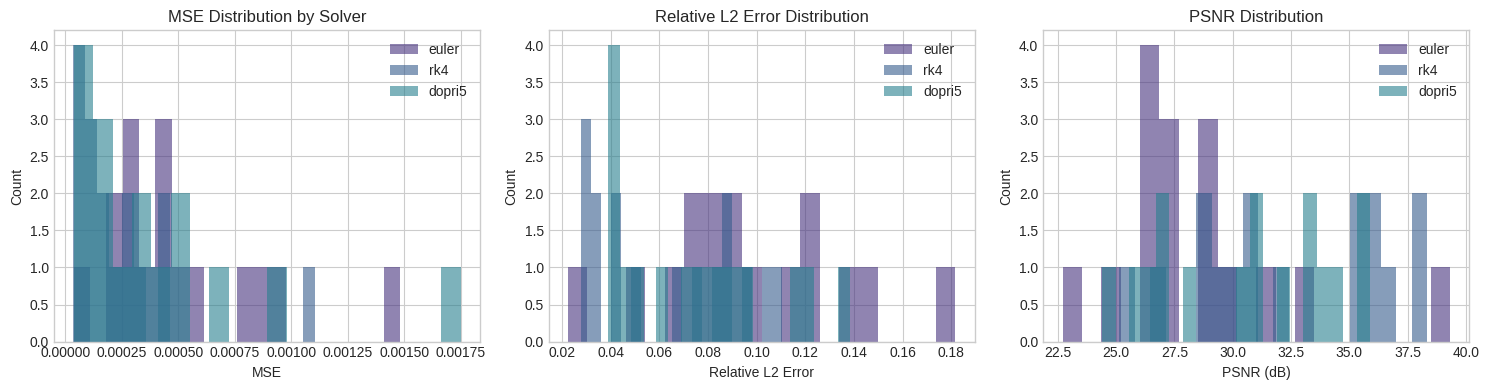

In [10]:
# Error distribution visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# MSE distribution
for solver, m in metrics_all.items():
    axes[0].hist(m['mse'].numpy(), bins=20, alpha=0.6, label=solver)
axes[0].set_xlabel('MSE')
axes[0].set_ylabel('Count')
axes[0].set_title('MSE Distribution by Solver')
axes[0].legend()

# Relative L2 distribution
for solver, m in metrics_all.items():
    axes[1].hist(m['rel_l2'].numpy(), bins=20, alpha=0.6, label=solver)
axes[1].set_xlabel('Relative L2 Error')
axes[1].set_ylabel('Count')
axes[1].set_title('Relative L2 Error Distribution')
axes[1].legend()

# PSNR distribution
for solver, m in metrics_all.items():
    axes[2].hist(m['psnr'].numpy(), bins=20, alpha=0.6, label=solver)
axes[2].set_xlabel('PSNR (dB)')
axes[2].set_ylabel('Count')
axes[2].set_title('PSNR Distribution')
axes[2].legend()

plt.tight_layout()
plt.show()

## 5. Flow Trajectory Visualization

Shows how the model transforms noise into the solution over time.

In [11]:
def generate_trajectory(flow, condition, n_steps=50):
    """
    Generate the full flow trajectory from noise to solution.
    """
    from flowpde.solvers import ODEFlowSolver
    
    flow.model.eval()
    device = next(flow.model.parameters()).device
    
    condition_flat = condition.flatten(start_dim=1).to(device)
    batch_size, dim = condition_flat.shape
    
    # Sample initial noise
    x_init = torch.randn(batch_size, dim, device=device)
    
    # Create time points
    t_eval = torch.linspace(0, 1, n_steps + 1, device=device)
    
    # Create velocity field wrapper
    from flowpde.solvers.ode_solvers import VelocityField
    velocity_field = VelocityField(flow.model, condition_flat)
    
    # Integrate with trajectory
    from torchdiffeq import odeint
    with torch.no_grad():
        trajectory = odeint(
            velocity_field,
            x_init,
            t_eval,
            method='rk4',
        )
    
    return trajectory.cpu(), t_eval.cpu()

# Generate trajectory for one sample
sample_idx = 0
condition = sources[sample_idx:sample_idx+1].to(device)

print("Generating flow trajectory...")
trajectory, t_eval = generate_trajectory(flow, condition, n_steps=20)
print(f"Trajectory shape: {trajectory.shape}")
print(f"Time points: {len(t_eval)}")

Generating flow trajectory...
Trajectory shape: torch.Size([21, 1, 4096])
Time points: 21


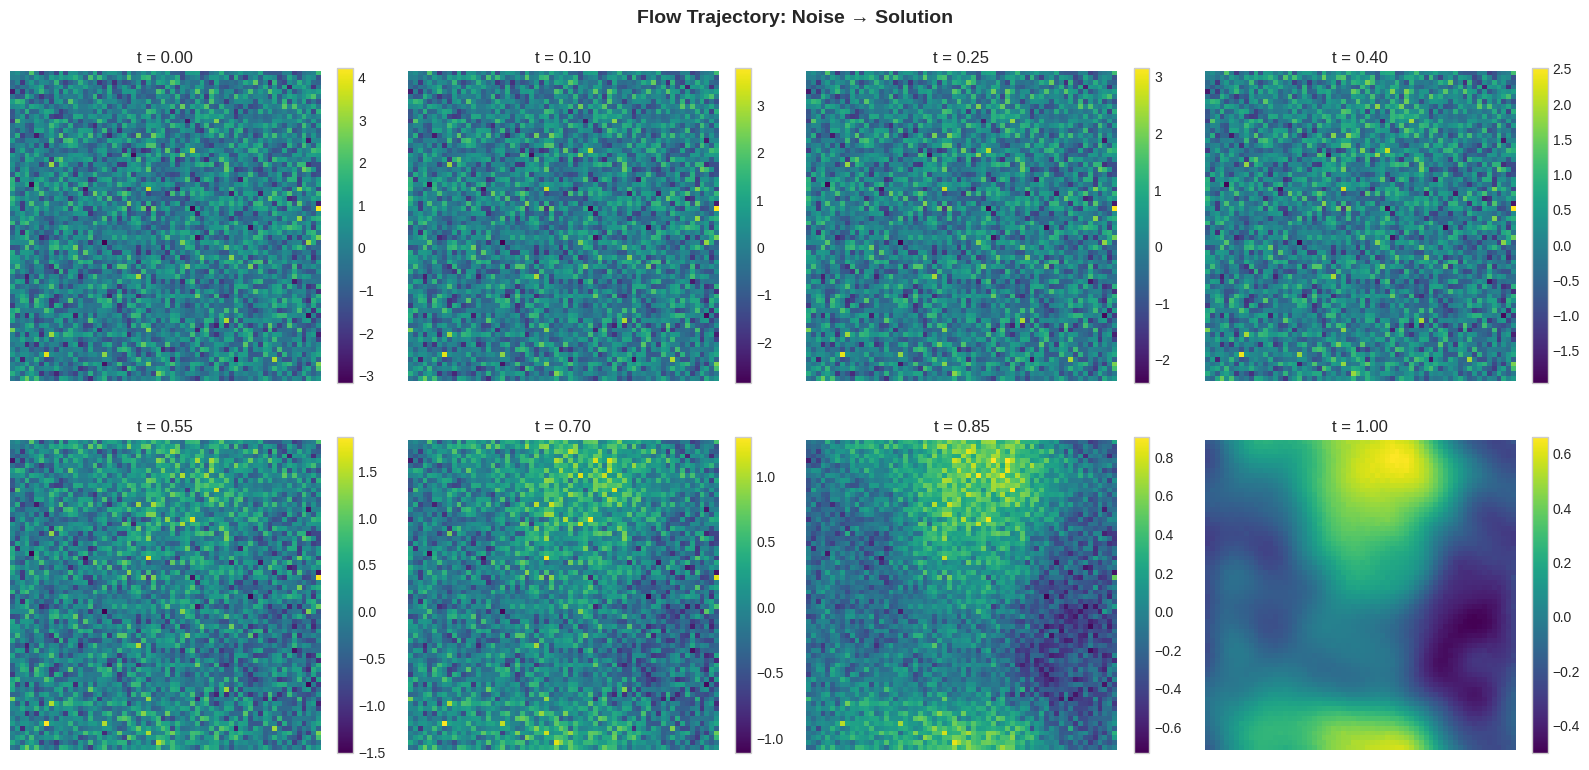

In [12]:
# Visualize the flow trajectory
n_frames = 8
frame_indices = np.linspace(0, len(trajectory) - 1, n_frames, dtype=int)

fig, axes = plt.subplots(2, n_frames // 2, figsize=(16, 8))
axes = axes.flatten()

for i, idx in enumerate(frame_indices):
    state = trajectory[idx, 0].view(SPATIAL_SIZE, SPATIAL_SIZE).numpy()
    t = t_eval[idx].item()
    
    im = axes[i].imshow(state, cmap='viridis')
    axes[i].set_title(f't = {t:.2f}', fontsize=12)
    axes[i].axis('off')
    plt.colorbar(im, ax=axes[i], fraction=0.046)

plt.suptitle('Flow Trajectory: Noise → Solution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

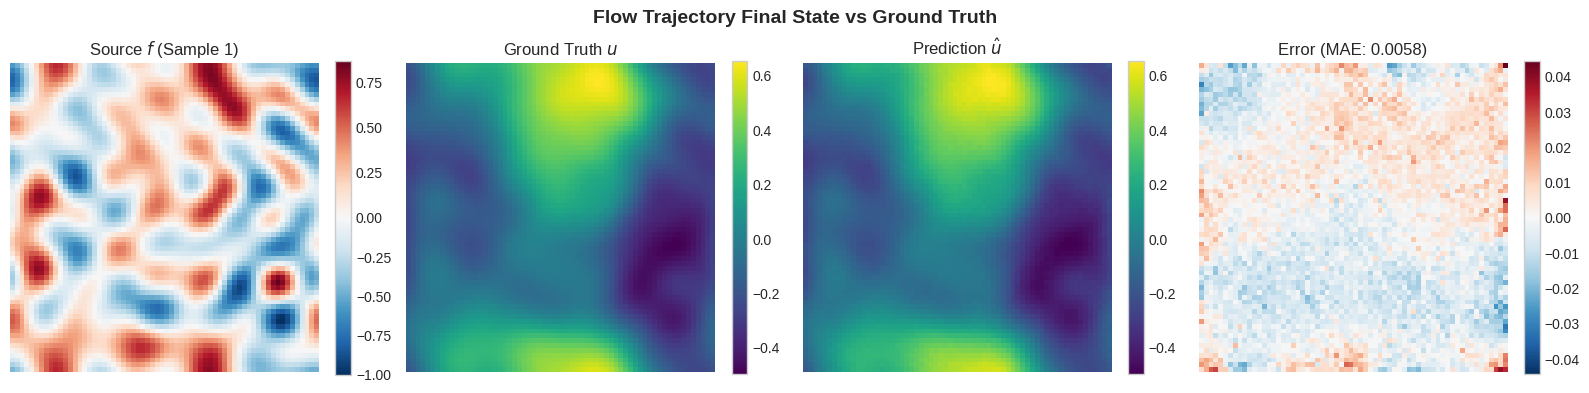

In [13]:
# Compare final trajectory state with ground truth
final_state = trajectory[-1, 0].view(1, 1, SPATIAL_SIZE, SPATIAL_SIZE)
gt_state = solutions_gt[sample_idx:sample_idx+1]

fig = plot_comparison(
    sources[sample_idx], gt_state[0], final_state[0],
    indices[sample_idx], title="Flow Trajectory Final State vs Ground Truth"
)
plt.show()

## 6. Spatial Error Analysis

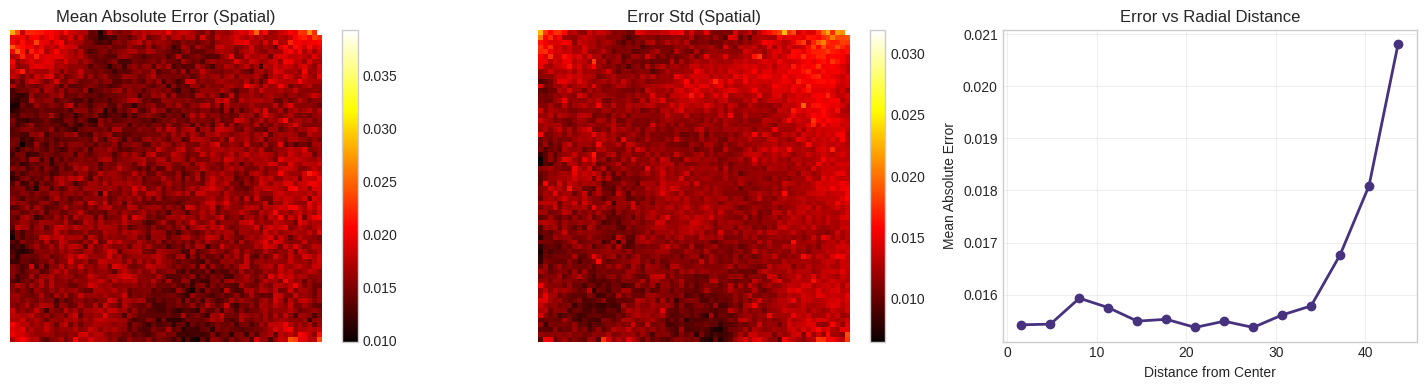

In [14]:
# Compute per-pixel error statistics across all samples
pred_best = predictions['dopri5']
pixel_errors = (pred_best - solutions_gt).abs()  # (N, 1, 64, 64)

# Mean and std of error at each pixel
mean_error_map = pixel_errors.mean(dim=0).squeeze().numpy()
std_error_map = pixel_errors.std(dim=0).squeeze().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Mean error map
im0 = axes[0].imshow(mean_error_map, cmap='hot')
axes[0].set_title('Mean Absolute Error (Spatial)', fontsize=12)
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Std error map
im1 = axes[1].imshow(std_error_map, cmap='hot')
axes[1].set_title('Error Std (Spatial)', fontsize=12)
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Error histogram by radial distance from center
center = SPATIAL_SIZE // 2
y, x = np.ogrid[:SPATIAL_SIZE, :SPATIAL_SIZE]
r = np.sqrt((x - center)**2 + (y - center)**2)

# Bin errors by radial distance
r_bins = np.linspace(0, center * np.sqrt(2), 15)
r_centers = 0.5 * (r_bins[:-1] + r_bins[1:])
radial_errors = []

for i in range(len(r_bins) - 1):
    mask = (r >= r_bins[i]) & (r < r_bins[i+1])
    radial_errors.append(mean_error_map[mask].mean())

axes[2].plot(r_centers, radial_errors, 'o-', linewidth=2, markersize=6)
axes[2].set_xlabel('Distance from Center')
axes[2].set_ylabel('Mean Absolute Error')
axes[2].set_title('Error vs Radial Distance', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Solver Convergence Analysis

Testing solver convergence...
n_steps=10: MSE=0.000517
n_steps=20: MSE=0.000305
n_steps=50: MSE=0.000483
n_steps=100: MSE=0.000364
n_steps=200: MSE=0.000511


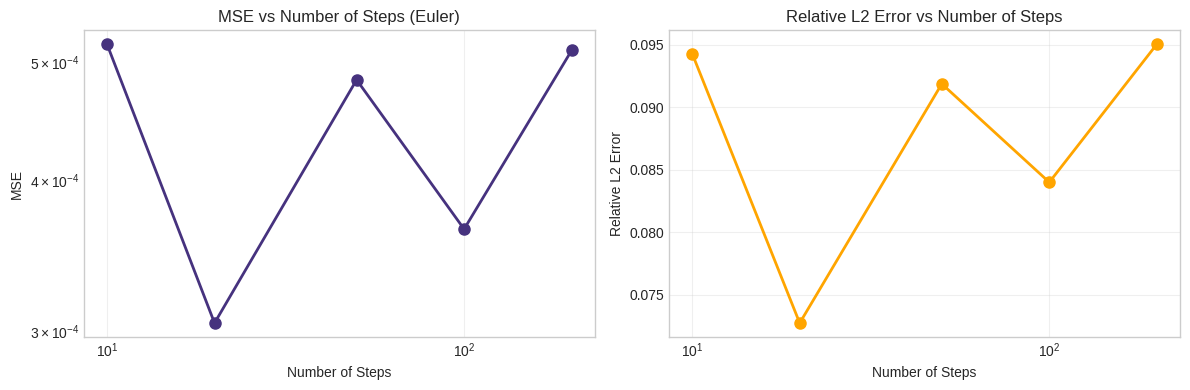

In [15]:
# Test convergence with different number of steps
step_counts = [10, 20, 50, 100, 200]
convergence_results = {}

print("Testing solver convergence...")
for n_steps in step_counts:
    pred = generate_samples(flow, sources_device, n_steps=n_steps, solver='euler')
    pred = pred.cpu().view(N_SAMPLES, 1, SPATIAL_SIZE, SPATIAL_SIZE)
    metrics = compute_metrics(pred, solutions_gt)
    convergence_results[n_steps] = {
        'mse': metrics['mse'].mean().item(),
        'rel_l2': metrics['rel_l2'].mean().item(),
    }
    print(f"n_steps={n_steps}: MSE={metrics['mse'].mean():.6f}")

# Plot convergence
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

steps = list(convergence_results.keys())
mse_vals = [convergence_results[s]['mse'] for s in steps]
rel_l2_vals = [convergence_results[s]['rel_l2'] for s in steps]

axes[0].loglog(steps, mse_vals, 'o-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Steps')
axes[0].set_ylabel('MSE')
axes[0].set_title('MSE vs Number of Steps (Euler)')
axes[0].grid(True, alpha=0.3)

axes[1].semilogx(steps, rel_l2_vals, 'o-', linewidth=2, markersize=8, color='orange')
axes[1].set_xlabel('Number of Steps')
axes[1].set_ylabel('Relative L2 Error')
axes[1].set_title('Relative L2 Error vs Number of Steps')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Stochasticity Analysis

Flow matching starts from random noise, so predictions vary. This section analyzes that variability.

In [16]:
# Generate multiple predictions for the same condition
N_RUNS = 10
single_condition = sources[0:1].to(device)

predictions_multi = []
for i in range(N_RUNS):
    pred = generate_samples(flow, single_condition, n_steps=50, solver='dopri5')
    predictions_multi.append(pred.cpu().view(1, SPATIAL_SIZE, SPATIAL_SIZE))

predictions_multi = torch.stack(predictions_multi, dim=0)  # (N_RUNS, 1, 64, 64)
print(f"Generated {N_RUNS} predictions for same input")
print(f"Predictions shape: {predictions_multi.shape}")

Generated 10 predictions for same input
Predictions shape: torch.Size([10, 1, 64, 64])


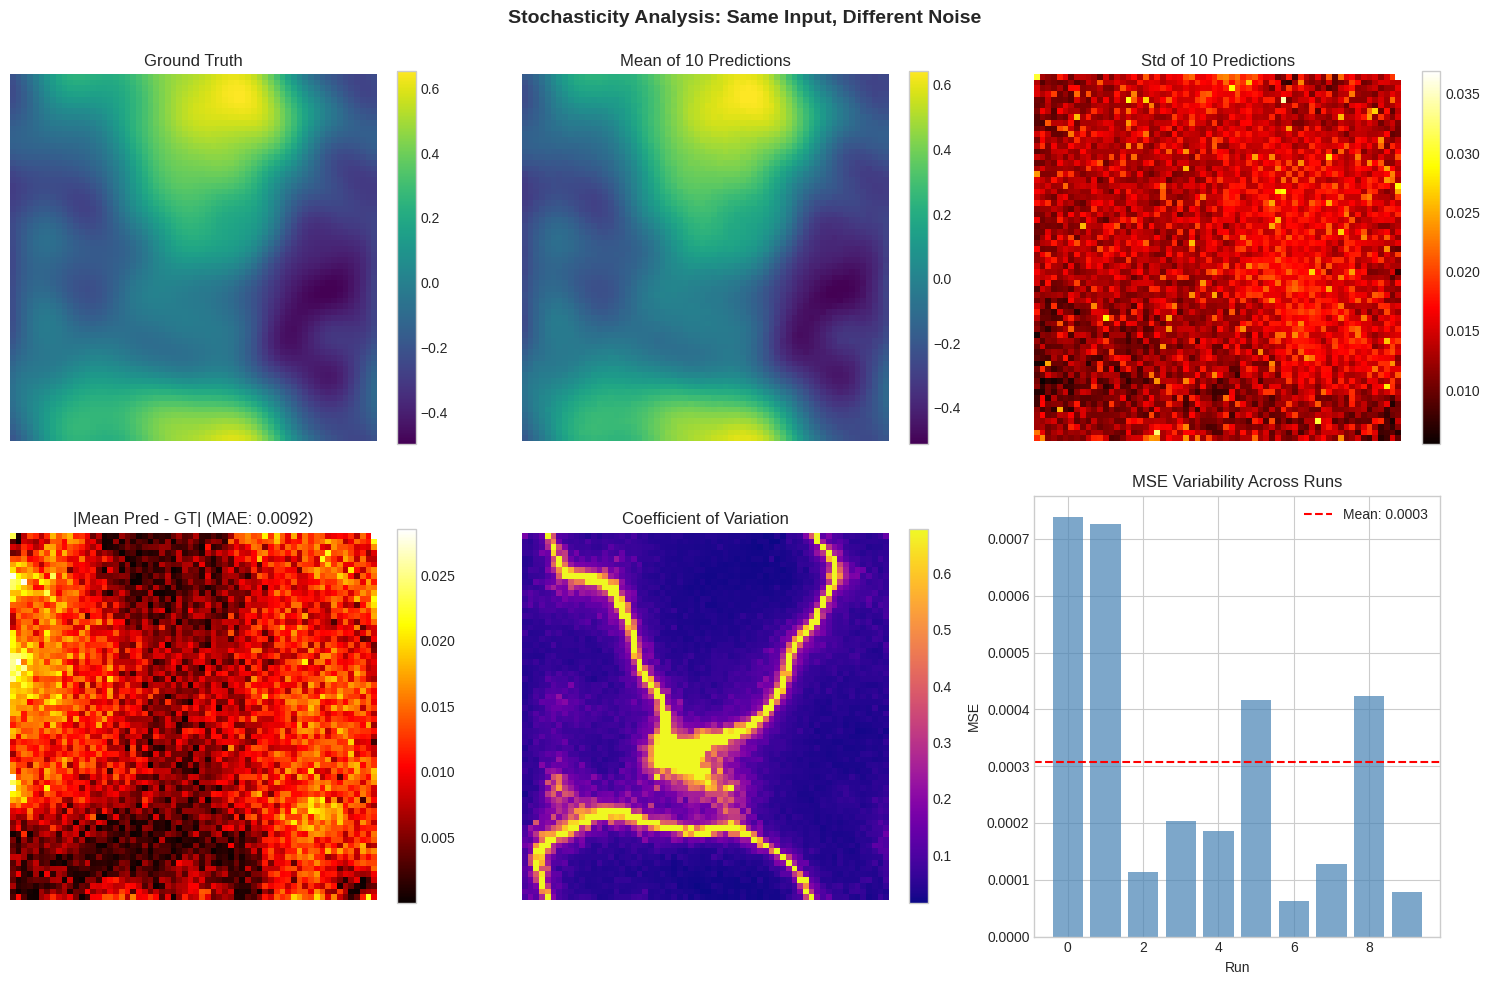


Stochasticity Summary:
   Mean prediction MSE: 0.000308 +/- 0.000244
   Max prediction std: 0.036936
   Mean prediction std: 0.014437


In [17]:
# Analyze variability
mean_pred = predictions_multi.mean(dim=0).squeeze().numpy()
std_pred = predictions_multi.std(dim=0).squeeze().numpy()
gt = solutions_gt[0].squeeze().numpy()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Predictions comparison
im0 = axes[0, 0].imshow(gt, cmap='viridis')
axes[0, 0].set_title('Ground Truth', fontsize=12)
axes[0, 0].axis('off')
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046)

im1 = axes[0, 1].imshow(mean_pred, cmap='viridis')
axes[0, 1].set_title(f'Mean of {N_RUNS} Predictions', fontsize=12)
axes[0, 1].axis('off')
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)

im2 = axes[0, 2].imshow(std_pred, cmap='hot')
axes[0, 2].set_title(f'Std of {N_RUNS} Predictions', fontsize=12)
axes[0, 2].axis('off')
plt.colorbar(im2, ax=axes[0, 2], fraction=0.046)

# Row 2: Error analysis
mean_error = np.abs(mean_pred - gt)
im3 = axes[1, 0].imshow(mean_error, cmap='hot')
axes[1, 0].set_title(f'|Mean Pred - GT| (MAE: {mean_error.mean():.4f})', fontsize=12)
axes[1, 0].axis('off')
plt.colorbar(im3, ax=axes[1, 0], fraction=0.046)

# Coefficient of variation
cv = std_pred / (np.abs(mean_pred) + 1e-8)
im4 = axes[1, 1].imshow(cv, cmap='plasma', vmax=np.percentile(cv, 95))
axes[1, 1].set_title('Coefficient of Variation', fontsize=12)
axes[1, 1].axis('off')
plt.colorbar(im4, ax=axes[1, 1], fraction=0.046)

# Histogram of per-run MSE
mse_per_run = [((predictions_multi[i].squeeze().numpy() - gt) ** 2).mean() for i in range(N_RUNS)]
axes[1, 2].bar(range(N_RUNS), mse_per_run, color='steelblue', alpha=0.7)
axes[1, 2].axhline(np.mean(mse_per_run), color='red', linestyle='--', label=f'Mean: {np.mean(mse_per_run):.4f}')
axes[1, 2].set_xlabel('Run')
axes[1, 2].set_ylabel('MSE')
axes[1, 2].set_title('MSE Variability Across Runs')
axes[1, 2].legend()

plt.suptitle('Stochasticity Analysis: Same Input, Different Noise', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nStochasticity Summary:")
print(f"   Mean prediction MSE: {np.mean(mse_per_run):.6f} +/- {np.std(mse_per_run):.6f}")
print(f"   Max prediction std: {std_pred.max():.6f}")
print(f"   Mean prediction std: {std_pred.mean():.6f}")